In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def initialize_lattice(lattice_size: int = 10):
    """Initialize a NxN lattice with random spins."""
    return np.random.choice([-1, 1], size=(lattice_size, lattice_size))

In [3]:
def metropolis_step(lattice, temperature):
    """Perform a single Metropolis step."""
    N = lattice.shape[0]
    beta = 1 / temperature  
    for _ in range(N*N):
        # Pick a random site
        i, j = np.random.randint(0, N, size=2)
        spin = lattice[i, j]
        
        # Calculate energy change if we flip this spin
        # We use periodic boundary conditions (modulo N)
        neighbors = (lattice[(i+1)%N, j] + lattice[(i-1)%N, j] +
                    lattice[i, (j+1)%N] + lattice[i, (j-1)%N])
        
        delta_E = 2 * spin * neighbors
        
        # Acceptance criteria
        if delta_E < 0 or np.random.rand() < np.exp(-delta_E * beta):
            lattice[i, j] *= -1
    return lattice

In [4]:
# Parameters
N = 50          # Lattice size (50x50)
T = 2.26        # Temperature (Near Critical Temp ~2.269)

# Run simulation
lattice = initialize_lattice(N)
for iteration in range(100):
    lattice = metropolis_step(lattice, T)

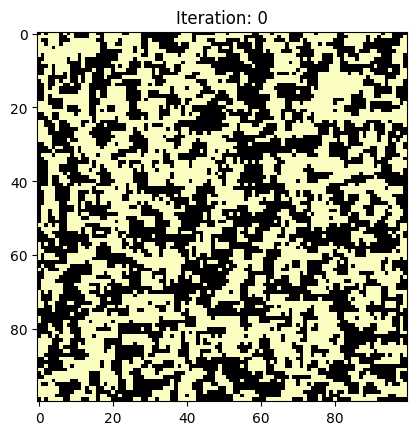

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

N = 100
T = 2.27
lattice = initialize_lattice(N)

fig, ax = plt.subplots()
img = ax.imshow(lattice, cmap='magma', interpolation='nearest')

def update(i):
    global lattice
    lattice = metropolis_step(lattice, T)
    img.set_data(lattice)
    ax.set_title(f"Iteration: {i}")
    return [img]

ani = FuncAnimation(fig, update, frames=200, blit=True)

ani.save("ising.gif", writer=PillowWriter(fps=20))